# Libreries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Config

In [2]:
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

# Data

In [3]:
df = pd.read_csv('/content/logistic_dataset.csv')

print('shape df', df.shape)

shape df (150000, 15)


In [4]:
display(df.head())

,package_id,customer_id,customer_type,delivery_date,delivery_days,package_value,package_weight_kg,delivery_cost,region,zone,provider,shipping_type,is_peak_season,is_profitable,distance_km
0,PKG000000,CUST1259,frecuente,2024-08-16,2.8,0.34,2.67,3.52,Arequipa,Sur,RapidBox,Normal,0,0,93.853618
1,PKG000001,CUST1354,nuevo,2024-12-25,1.4,0.69,0.82,4.16,Piura,Norte,FastCargo,Normal,1,0,602.024286
2,PKG000002,CUST0062,frecuente,2024-11-29,16.9,0.36,3.76,5.07,Tacna,Sur,RapidBox,Normal,1,0,263.349139
3,PKG000003,CUST0237,frecuente,2024-11-13,1.7,1.25,2.05,3.90,Callao,Centro,LogisticX,Normal,1,0,182.588511
4,PKG000004,CUST0419,nuevo,2024-04-05,3.2,1.10,1.32,2.73,Puno,Sur,LogisticX,Normal,0,0,33.924974


# EDA

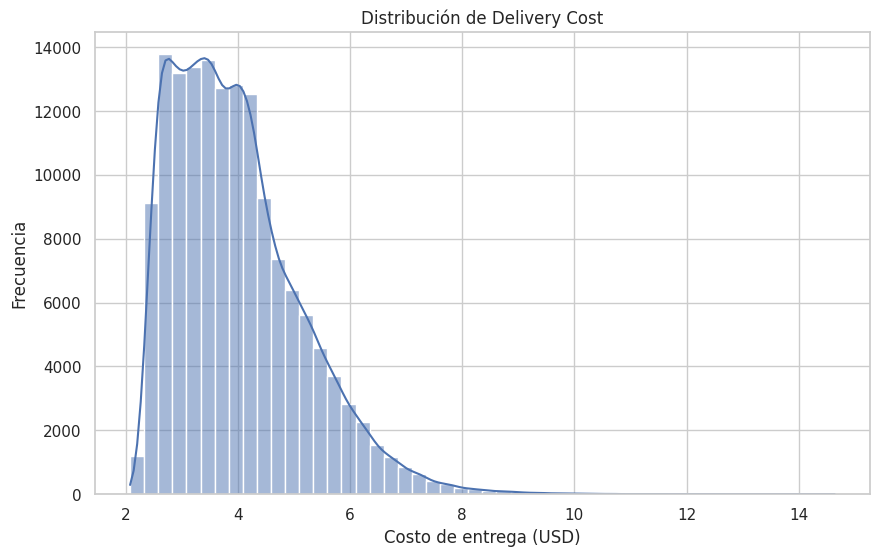

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df['delivery_cost'], bins=50, kde=True)
plt.title('Distribución de Delivery Cost')
plt.xlabel('Costo de entrega (USD)')
plt.ylabel('Frecuencia')
plt.show()

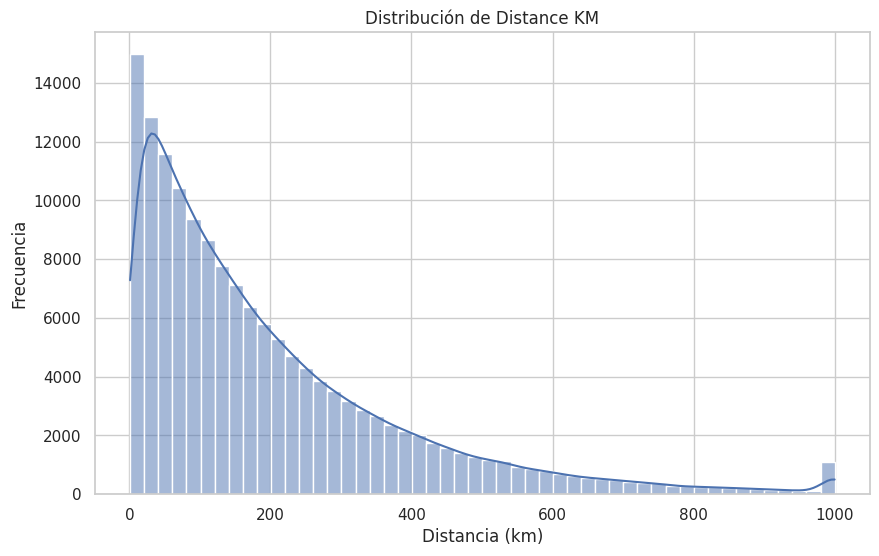

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df['distance_km'], bins=50, kde=True)
plt.title('Distribución de Distance KM')
plt.xlabel('Distancia (km)')
plt.ylabel('Frecuencia')
plt.show()

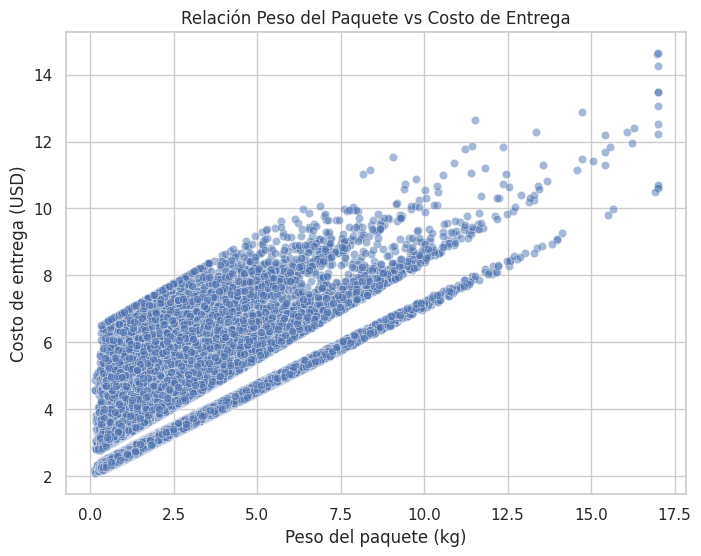

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['package_weight_kg'], y=df['delivery_cost'], alpha=0.5)
plt.title('Relación Peso del Paquete vs Costo de Entrega')
plt.xlabel('Peso del paquete (kg)')
plt.ylabel('Costo de entrega (USD)')
plt.show()

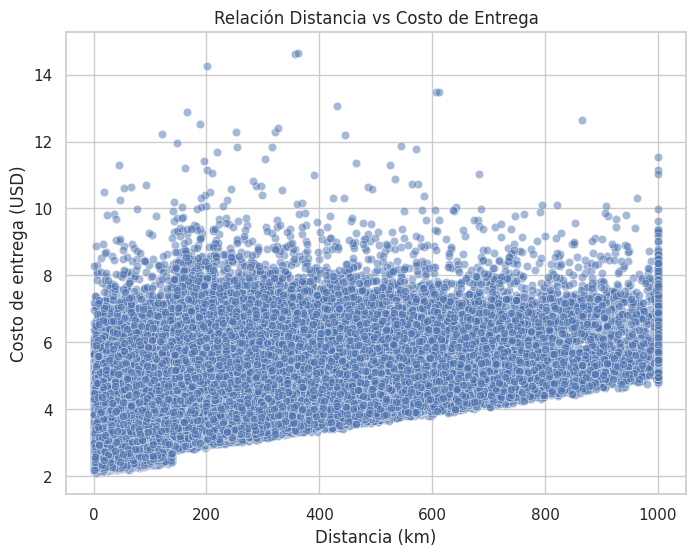

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['distance_km'], y=df['delivery_cost'], alpha=0.5)
plt.title('Relación Distancia vs Costo de Entrega')
plt.xlabel('Distancia (km)')
plt.ylabel('Costo de entrega (USD)')
plt.show()

# Splits

In [13]:
features_num = [
    'package_weight_kg',
    'package_value',
    'delivery_days',
    'distance_km',
    'is_peak_season',
    'is_profitable'
]


features_categoricas = [
    'shipping_type',
    'provider',
    'region',
    'zone',
    'customer_type'
]

In [14]:
X_numericas = df[features_num].copy()
X_categoricas = pd.get_dummies(df[features_categoricas])

In [15]:
X_features = pd.concat([X_numericas, X_categoricas], axis=1)

In [16]:
y_target = df['delivery_cost'].copy()

In [17]:
print("Features y target listos:")
print("X_features shape:", X_features.shape)
print("y_target shape:", y_target.shape)


Features y target listos:
X_features shape: (150000, 46)
y_target shape: (150000,)


In [18]:
X_train_cost, X_test_cost, y_train_cost, y_test_cost = train_test_split(X_features, y_target, test_size=0.2,  random_state=42)

In [19]:
print("X_train_cost shape:", X_train_cost.shape)
print("y_train_cost shape:", y_train_cost.shape)

X_train_cost shape: (120000, 46)
y_train_cost shape: (120000,)


# Random Forest Regressor

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [21]:
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_regressor.fit(X_train_cost, y_train_cost)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [22]:
y_pred_rf = rf_regressor.predict(X_test_cost)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_cost, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test_cost, y_pred_rf))
r2 = r2_score(y_test_cost, y_pred_rf)

print("📊 Evaluación del Random Forest Regressor:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

📊 Evaluación del Random Forest Regressor:
MAE: 0.0046
RMSE: 0.0139
R2 Score: 0.9999


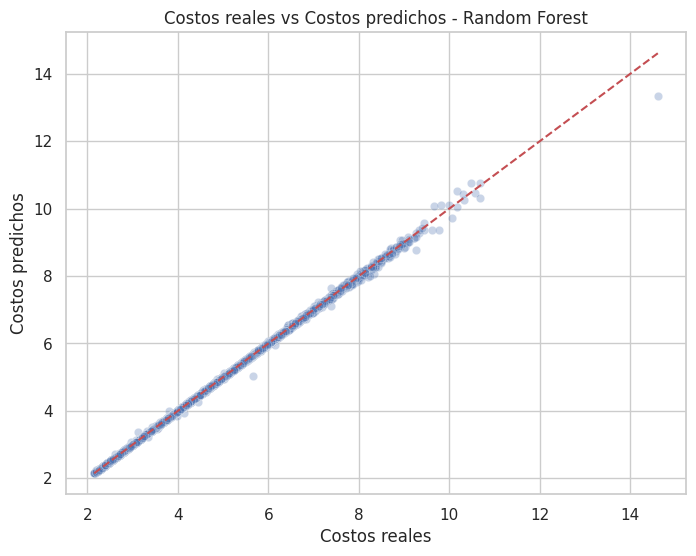

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_cost, y=y_pred_rf, alpha=0.3)
plt.plot([y_test_cost.min(), y_test_cost.max()], [y_test_cost.min(), y_test_cost.max()], 'r--')
plt.title('Costos reales vs Costos predichos - Random Forest')
plt.xlabel('Costos reales')
plt.ylabel('Costos predichos')
plt.show()

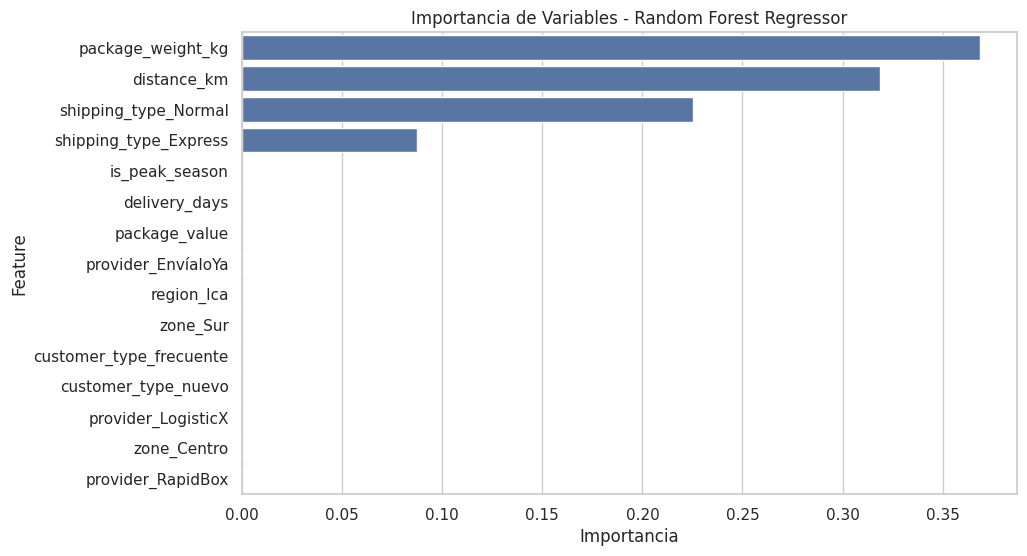

In [25]:
importances = rf_regressor.feature_importances_
features = X_train_cost.columns

# Crear dataframe ordenado
importances_df = pd.DataFrame({'feature': features, 'importance': importances})
importances_df = importances_df.sort_values(by='importance', ascending=False)

# Gráfico
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=importances_df.head(15))
plt.title('Importancia de Variables - Random Forest Regressor')
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.show()

# XGBoost Regressor

In [26]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

xgb_regressor = XGBRegressor(m_estimators=100, learning_rate=0.1, max_depth=6, subsample=0.8, colsample_by_tree=0.8, random_state=42, n_jobs=-1)

xgb_regressor.fit(X_train_cost, y_train_cost)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:22:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "colsample_by_tree", "m_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_by_tree=0.8, colsample_bylevel=None,
             colsample_bynode=None, colsample_bytree=None, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, m_estimators=100, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=-1, ...)

In [27]:
y_pred_xgb = xgb_regressor.predict(X_test_cost)

mae_xgb = mean_absolute_error(y_test_cost, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_cost, y_pred_xgb))
r2_xgb = r2_score(y_test_cost, y_pred_xgb)

print("📊 Evaluación del XGBoost Regressor:")
print(f"MAE: {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R2 Score: {r2_xgb:.4f}")

📊 Evaluación del XGBoost Regressor:
MAE: 0.0155
RMSE: 0.0558
R2 Score: 0.9976


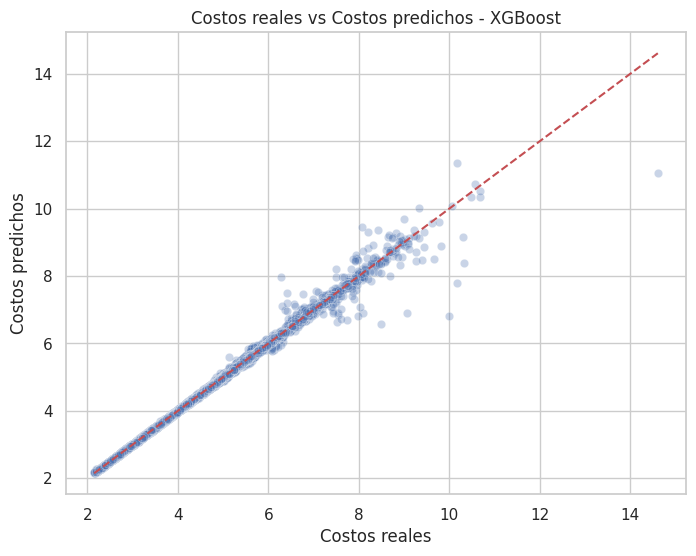

In [28]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_cost, y=y_pred_xgb, alpha=0.3)
plt.plot([y_test_cost.min(), y_test_cost.max()], [y_test_cost.min(), y_test_cost.max()], 'r--')
plt.title('Costos reales vs Costos predichos - XGBoost')
plt.xlabel('Costos reales')
plt.ylabel('Costos predichos')
plt.show()

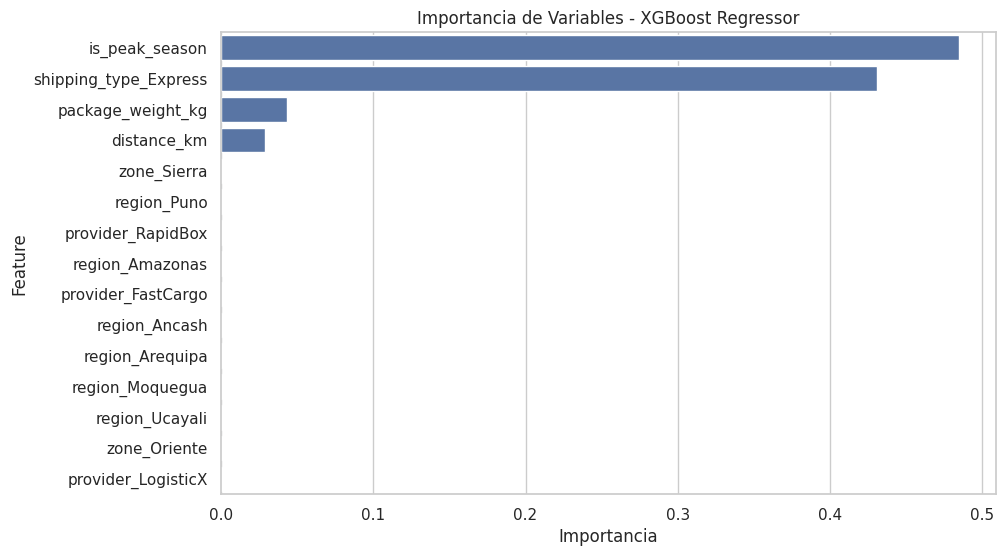

In [29]:
importances_xgb = xgb_regressor.feature_importances_
features_xgb = X_train_cost.columns

importances_df_xgb = pd.DataFrame({'feature': features_xgb, 'importance': importances_xgb})
importances_df_xgb = importances_df_xgb.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=importances_df_xgb.head(15))
plt.title('Importancia de Variables - XGBoost Regressor')
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.show()

# LightGBM

In [30]:
from lightgbm import LGBMRegressor

lgbm_regressor = LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=-1, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)

In [31]:
lgbm_regressor.fit(X_train_cost, y_train_cost)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024616 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1011
[LightGBM] [Info] Number of data points in the train set: 120000, number of used features: 46
[LightGBM] [Info] Start training from score 3.982805


LGBMRegressor(colsample_bytree=0.8, n_jobs=-1, random_state=42, subsample=0.8)

In [32]:
y_pred_lgbm = lgbm_regressor.predict(X_test_cost)

# 🚀 Cálculo de métricas
mae_lgbm = mean_absolute_error(y_test_cost, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test_cost, y_pred_lgbm))
r2_lgbm = r2_score(y_test_cost, y_pred_lgbm)

print("📊 Evaluación del LightGBM Regressor:")
print(f"MAE: {mae_lgbm:.4f}")
print(f"RMSE: {rmse_lgbm:.4f}")
print(f"R2 Score: {r2_lgbm:.4f}")

📊 Evaluación del LightGBM Regressor:
MAE: 0.0165
RMSE: 0.0477
R2 Score: 0.9983


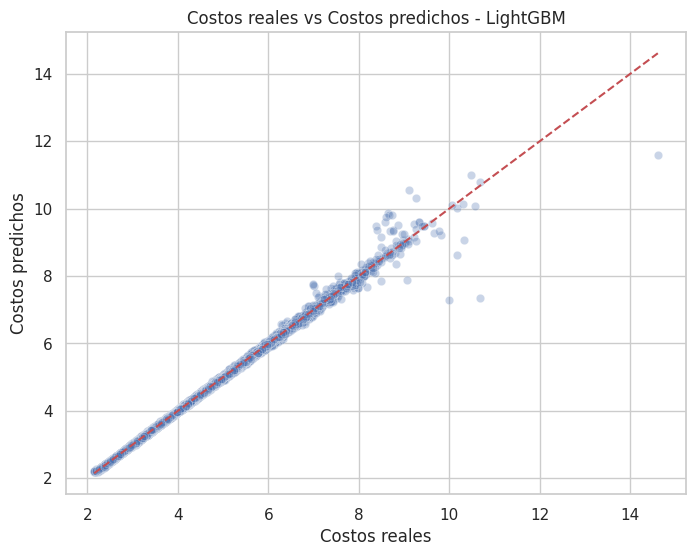

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_cost, y=y_pred_lgbm, alpha=0.3)
plt.plot([y_test_cost.min(), y_test_cost.max()], [y_test_cost.min(), y_test_cost.max()], 'r--')
plt.title('Costos reales vs Costos predichos - LightGBM')
plt.xlabel('Costos reales')
plt.ylabel('Costos predichos')
plt.show()

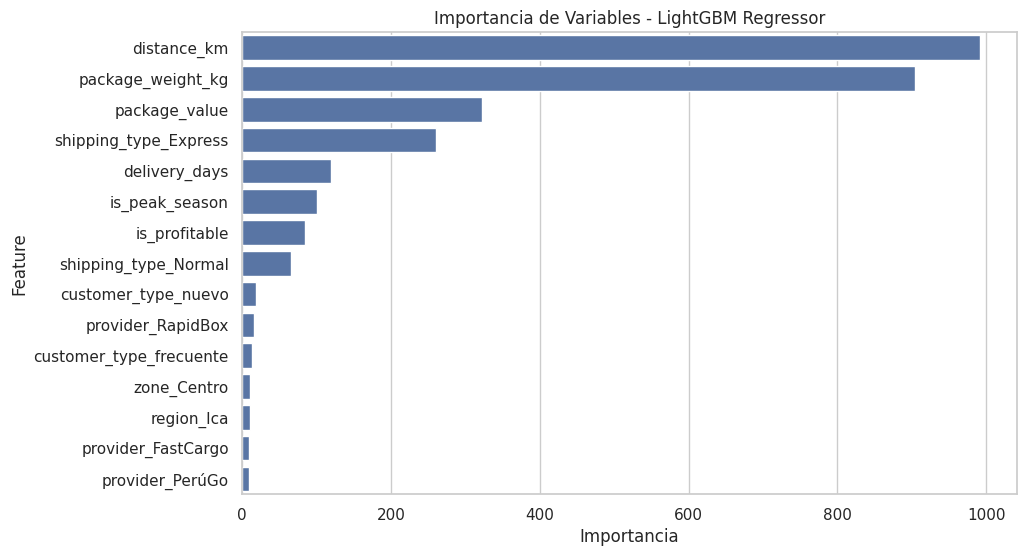

In [34]:
importances_lgbm = lgbm_regressor.feature_importances_
features_lgbm = X_train_cost.columns

importances_df_lgbm = pd.DataFrame({'feature': features_lgbm, 'importance': importances_lgbm})
importances_df_lgbm = importances_df_lgbm.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=importances_df_lgbm.head(15))
plt.title('Importancia de Variables - LightGBM Regressor')
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.show()

In [37]:
import pickle

# Guardamos el modelo entrenado
modelo_path = "random_forest_regressor.pkl"
with open(modelo_path, "wb") as file:
    pickle.dump(rf_regressor, file)

print(f"Modelo guardado correctamente en {modelo_path}")

✅ Modelo guardado correctamente en random_forest_regressor.pkl


# Scripts de test

In [38]:
# Cargar el modelo
modelo_path = "/content/random_forest_regressor.pkl"
with open(modelo_path, "rb") as file:
    modelo = pickle.load(file)

In [39]:
X_train_cost.columns

Index(['package_weight_kg', 'package_value', 'delivery_days', 'distance_km',
       'is_peak_season', 'is_profitable', 'shipping_type_Express',
       'shipping_type_Normal', 'provider_EnvíaloYa', 'provider_FastCargo',
       'provider_LogisticX', 'provider_PerúGo', 'provider_RapidBox',
       'region_Amazonas', 'region_Ancash', 'region_Apurímac',
       'region_Arequipa', 'region_Ayacucho', 'region_Cajamarca',
       'region_Callao', 'region_Cusco', 'region_Huancavelica',
       'region_Huánuco', 'region_Ica', 'region_Junín', 'region_La Libertad',
       'region_Lambayeque', 'region_Lima', 'region_Loreto',
       'region_Madre de Dios', 'region_Moquegua', 'region_Pasco',
       'region_Piura', 'region_Puno', 'region_San Martín', 'region_Tacna',
       'region_Tumbes', 'region_Ucayali', 'zone_Centro', 'zone_Norte',
       'zone_Oriente', 'zone_Sierra', 'zone_Sur', 'customer_type_frecuente',
       'customer_type_nuevo', 'customer_type_premium'],
      dtype='object')

In [41]:
nuevo_paquete = pd.DataFrame({
    'package_weight_kg': [2.5],
    'package_value': [50],
    'delivery_days': [3],
    'distance_km': [150],
    'is_peak_season': [0],
    'is_profitable': [1],
    'shipping_type_Express': [0],
    'shipping_type_Normal': [1],
    'provider_EnvíaloYa': [0],
    'provider_FastCargo': [0],
    'provider_LogisticX': [0],
    'provider_PerúGo': [0],
    'provider_RapidBox': [0],
    'region_Amazonas': [0],
    'region_Ancash': [0],
    'region_Apurímac': [0],
    'region_Arequipa': [0],
    'region_Ayacucho': [0],
    'region_Cajamarca': [0],
    'region_Callao': [0],
    'region_Cusco': [0],
    'region_Huancavelica': [0],
    'region_Huánuco': [0],
    'region_Ica': [0],
    'region_Junín': [0],
    'region_La Libertad': [0],
    'region_Lambayeque': [0],
    'region_Lima': [1],  # Por ejemplo este sí está en Lima
    'region_Loreto': [0],
    'region_Madre de Dios': [0],
    'region_Moquegua': [0],
    'region_Pasco': [0],
    'region_Piura': [0],
    'region_Puno': [0],
    'region_San Martín': [0],
    'region_Tacna': [0],
    'region_Tumbes': [0],
    'region_Ucayali': [0],
    'zone_Centro': [1],   # Por ejemplo aquí sí pertenece a Zona Centro
    'zone_Norte': [0],
    'zone_Oriente': [0],
    'zone_Sierra': [0],
    'zone_Sur': [0],
    'customer_type_frecuente': [0],
    'customer_type_nuevo': [1],
    'customer_type_premium': [0]
})

# Predecir el costo de entrega
costo_predicho = modelo.predict(nuevo_paquete)

print(f"Costo de entrega predicho: {costo_predicho[0]:.2f} USD")

Costo de entrega predicho: 3.98 USD
